# Lesson 11 — From Resonance Absorption to Neutron Thermalization

By the end of this lesson, you should be able to:

1. Extend the Lesson 10 uranium–water calculation below 1 eV without killing thermal neutrons.
2. Explain upscatter, detailed balance, and the role of an $S(\alpha,\beta)$ scattering law.
3. Compare the computed thermal **flux** with $E\exp[-E/(k_BT)]$.
4. Separate temperature effects, absorption-induced hardening, and plotting normalization.

## 1. What changes from Lesson 10?

Keep the natural-uranium/water material, 1 MeV incident neutrons, and reflective
sphere. Change these specific details:

| Lesson 10 | Lesson 11 |
|---|---|
| Neutrons are terminated below 1 eV | Remove that transport cutoff |
| Resonance-range flux bins | Include the thermal region and the incident source energy |
| Free-atom scattering treatment | Add `c_H_in_H2O` for bound hydrogen in water |
| Arbitrarily scaled flux curve | Report bin-integrated tallies per source neutron, with explicit volume/bin normalization |

For this thermalization experiment, explicitly set
`create_fission_neutrons=False`: the uranium can absorb/fission, but its fission
descendants are not transported. This isolates the response to the specified
1 MeV source. **A fixed-source calculation does not automatically suppress
fission descendants.** Lesson 12 will turn their transport on deliberately.

In [1]:
import openmc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# GLOBAL CONSTANTS
TEMPERATURE = 294.0
RADIUS = 1.0 # cm, same reflective sphere as Lesson 10
VOLUME = 4.0 * np.pi * RADIUS**3 / 3.0
K_B = 8.617333262e-5  # eV/K
ENERGY_EDGES = np.geomspace(1e-5, 2e7, 1001)  # geomspace like logspace but with absolute points
ENERGY = np.sqrt(ENERGY_EDGES[:-1] * ENERGY_EDGES[1:]) # "center energy"
DELTA_E = np.diff(ENERGY_EDGES)
DELTA_U = np.log(ENERGY_EDGES[1:] / ENERGY_EDGES[:-1])

PURPLE="#512888"
ORANGE="#CA7C1B"

## 2. Materials, geometry, and source: the familiar model


In [2]:
def make_model(H_to_U=100.0, temperature=294, bound_hydrogen=True,
               multiplying=False, particles=2000, batches=40, seed=11001):
    """Lesson 10's material/geometry/source, extended through thermal energies.
    """
    material = openmc.Material(name="natural U + water")
    
    # Bypass U with H_to_U set to None
    N_U = 1.0
    if H_to_U is None:
        H_to_U = 2
        N_U = 0
        
    material.add_nuclide("H1", float(H_to_U))
    material.add_nuclide("O16", float(H_to_U) / 2.0)
    material.add_element("U", N_U)  # Use OpenMC's natural isotopic abundances
    material.set_density("g/cm3", 1.0)
    material.temperature = float(temperature)
    if bound_hydrogen:
        material.add_s_alpha_beta("c_H_in_H2O")

    sphere = openmc.Sphere(r=RADIUS, boundary_type="reflective")
    
    cell = openmc.Cell(fill=material, region=-sphere)
    
    settings = openmc.Settings()
    settings.run_mode = "fixed source"
    settings.source = openmc.IndependentSource(
        space=openmc.stats.Point((0.0, 0.0, 0.0)),
        energy=openmc.stats.Discrete([1e6], [1.0]),
    )
    settings.particles = int(particles)
    settings.batches = int(batches)
    settings.seed = int(seed)
    settings.create_fission_neutrons = bool(multiplying)
    
    materials = openmc.Materials([material])
    
    model = openmc.Model(geometry=openmc.Geometry([cell]), materials=materials, settings=settings)
    
    tally = openmc.Tally(name="spectrum")
    tally.filters = [openmc.CellFilter(cell), openmc.EnergyFilter(ENERGY_EDGES)]
    tally.scores = ["flux"]
    tally.estimator = "tracklength"
    model.tallies = openmc.Tallies([tally])
    
    return model, material, cell

## 3. Tally and normalize the spectrum correctly

For energy bin $g$, OpenMC's cell-filtered track-length `flux` score is

$$T_{\phi,g}=\frac{1}{N_{\rm source}}\sum_{\text{tracks in }V,g}w\ell.$$

It is already normalized **per source neutron** and integrated over the cell
and energy bin. Thus

$$\bar\phi_g \simeq \frac{T_{\phi,g}}{V\,\Delta E_g},\qquad
\bar\phi_{u,g}=\frac{T_{\phi,g}}{V\,\ln(E_{g+1}/E_g)}\simeq E\bar\phi(E).$$

Do **not** multiply by the number of particles or batches. To specify an
external source strength $Q$ in neutrons/s, multiply these per-source results
by $Q$; only then do the axes acquire a per-second unit. The plotting grid is
not a transport cutoff.

In [3]:
def get_results(sp_path):
    with openmc.StatePoint(sp_path) as sp:
        tally = sp.get_tally(name="spectrum")
        mean = tally.get_values(scores=["flux"], value="mean").ravel().copy()
        sd = tally.get_values(scores=["flux"], value="std_dev").ravel().copy()
        results = {"bin_flux": mean, "bin_sd": sd,
                   "phi_E": mean / (VOLUME * DELTA_E),
                   "phi_u": mean / (VOLUME * DELTA_U)}
        return results

In [4]:
water_no_sab, _, _ = make_model(H_to_U=None, bound_hydrogen=False)
water_sab, _, _ = make_model(H_to_U=None, bound_hydrogen=True)

**To avoid overlapping outputs, we need to run each case and get its results before running another model.**

In [5]:
sp_no_sab = water_no_sab.run(output=False)
results_no_sab = get_results(sp_no_sab)

In [6]:
sp_sab = water_sab.run(output=False)
results_sab = get_results(sp_sab)

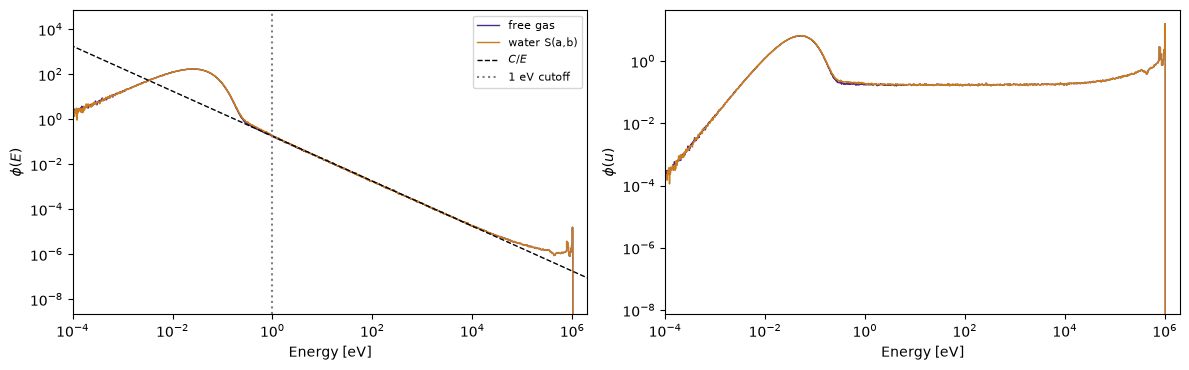

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

axes[0].stairs(results_no_sab["phi_E"], ENERGY_EDGES, label="free gas", color=PURPLE)
axes[0].stairs(results_sab["phi_E"], ENERGY_EDGES, label="water S(a,b)", color=ORANGE)

epithermal = (ENERGY >= 1e3) & (ENERGY <= 1e4) & (results_no_sab["phi_E"] > 0)
C = np.median(ENERGY[epithermal] * results_no_sab["phi_E"][epithermal])

axes[0].plot(ENERGY, C / ENERGY, "k--", lw=1, label=r"$C/E$")
axes[0].set(xscale="log", yscale="log", xlim=(1e-4, 2e6), ylabel=r"$\phi(E)$", xlabel="Energy [eV]")
axes[0].axvline(1.0, color="gray", ls=":", label="1 eV cutoff")
axes[0].legend(fontsize=8)

axes[1].stairs(results_no_sab["phi_u"], ENERGY_EDGES, color=PURPLE)
axes[1].stairs(results_sab["phi_u"], ENERGY_EDGES, color=ORANGE)

axes[1].set(xscale="log", yscale="log", xlim=(1e-4, 2e6),
            xlabel="Energy [eV]", ylabel=r"$\phi(u)$")

fig.tight_layout()
plt.show()

**Pause and predict.** What appears below the old 1 eV cutoff? Where are the
uranium resonance depressions (if U is included)? Why does a $1/E$ spectrum become approximately
flat when plotted per unit lethargy?

## 4. Thermal balance, detailed balance, and the correct Maxwellian

For thermal energies, the infinite-medium balance can be written schematically as

$$\Sigma_t(E)\phi(E)=\int_{\rm thermal}\Sigma_s(E'\!\to E)\phi(E')\,dE'
  +q_{\rm into\ thermal}(E).$$

The scattering kernel includes both downscatter and **upscatter**. At thermal
equilibrium, detailed balance makes the equilibrium-weighted forward and
reverse scattering flows equal. Ignoring absorption and the imposed source,
this leads to the Maxwell–Boltzmann equilibrium shape.

For the energy-transfer kernel, **detailed balance** is expressed as

$$\Sigma_s(E'\!\to E)\phi_{\rm MB}(E')
  =\Sigma_s(E\!\to E')\phi_{\rm MB}(E).$$

Be precise about the quantity: neutron **number density** per unit energy is
$n(E)\propto\sqrt E\,e^{-E/(k_BT)}$, but scalar **flux** is $v(E)n(E)$, so

$$\phi_{\rm MB}(E)\propto E\,e^{-E/(k_BT)}.$$

Its peak is at $E=k_BT$ (about 0.0253 eV at 294 K). An absorbing,
externally driven medium need not be exactly Maxwellian. Absorption, bound-atom
scattering, and the continuing supply of slowing-down neutrons distort it.

## 5. Controlled comparisons: binding, temperature, and absorption

The no-$S(\alpha,\beta)$ case is the **free-gas** comparison. It still has
thermal motion; it is not a model in which neutrons can only lose energy.
The bound-water law also represents molecular binding and motions.


In [8]:
water_no_sab_600K, _, _ = make_model(H_to_U=None, bound_hydrogen=False, temperature=600.0)
water_sab_600K, _, _ = make_model(H_to_U=None, bound_hydrogen=True, temperature=600.0)

sp_no_sab_600K = water_no_sab_600K.run(output=False)
results_no_sab_600K = get_results(sp_no_sab_600K)

sp_sab_600K = water_no_sab_600K.run(output=False)
results_sab_600K = get_results(sp_sab_600K)

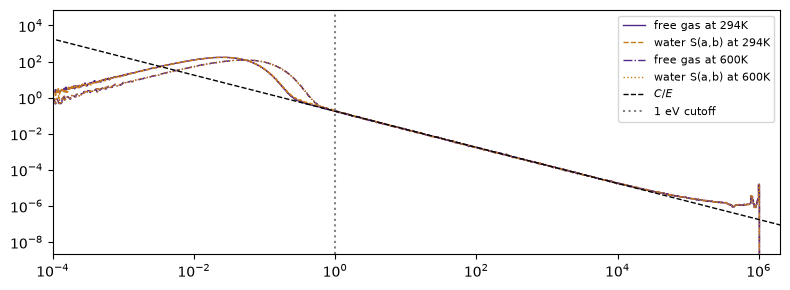

In [9]:
plt.figure(figsize=(8, 3))

plt.stairs(results_no_sab["phi_E"], ENERGY_EDGES, label="free gas at 294K", color=PURPLE)
plt.stairs(results_sab["phi_E"], ENERGY_EDGES, label="water S(a,b) at 294K", color=ORANGE, ls="--")
plt.stairs(results_no_sab_600K["phi_E"], ENERGY_EDGES, label="free gas at 600K", color=PURPLE, ls="-.")
plt.stairs(results_sab_600K["phi_E"], ENERGY_EDGES, label="water S(a,b) at 600K", color=ORANGE, ls=":")

plt.plot(ENERGY, C / ENERGY, "k--", lw=1, label=r"$C/E$")
plt.xscale("log")  
plt.xlim(1e-4, 2e6)
plt.yscale("log") 
plt.ylabel=r"$\phi(E)$"
plt.xlabel="Energy [eV]"
plt.axvline(1.0, color="gray", ls=":", label="1 eV cutoff")
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 6. Ponderables

1. Use $k_BT$ to predict the thermal-flux peak at 294 K and 600 K. Does the
   simulated peak move as predicted? Explain departures from the ideal shape.
2. Explain why adding more absorber can harden the thermal spectrum. Compare
   H/U=100 with H/U=5 at the **same temperature** before comparing temperatures.
3. Increase `particles` and rerun one comparison. Identify a physical change
   versus a noisy tail; do not interpret empty/poorly sampled bins as exact zeros.

**Next:** a flux shape matters because reaction rates weight it by energy-dependent
cross sections. In Lesson 12 we add `nu-fission` and `absorption` scores, compute
effective macroscopic cross sections, and replace the imposed source by a
self-consistent fission source.